# From Face to Form  
### An Emotion-Driven Recursive Generative Art System  

**IAT 460 | Manmeet Sagri | Student #: 301545311**

This project explores how facial emotion probabilities extracted from cinematic scenes can be transformed into evolving generative fractal structures.

Instead of representing emotion as static labels or analytics, this system translates probabilistic emotion data into visual form through a recursive generative process.

----
## Project Concept

*From Face to Form* is a creative AI system that translates facial expression probabilities from a video clip into a generative fractal visualization.

Rather than displaying emotion as numerical labels alone, the system reinterprets probabilistic emotion classifications as generative signals that drive visual change. Emotions such as happiness, sadness, fear, anger, and surprise can later influence structural properties such as recursion depth, branching behavior, and color palette.

This notebook documents the first working prototype of the pipeline, focusing on video preprocessing, face detection, emotion classification, and an initial emotion-to-fractal mapping.

## System Pipeline

The current prototype follows this multi-stage pipeline:

1. Video Input  
2. Frame Sampling  
3. Face Detection  
4. Emotion Classification  
5. Emotion-to-Fractal Mapping  
6. Side-by-Side Prototype Output  

At this stage, the goal is to establish a clear working relationship between facial input, emotion probabilities, and generative visual output.

## Step 1: Install Required Libraries

This section installs the libraries needed for:

- video reading and preprocessing
- image display
- face detection
- pretrained emotion classification
- fractal generation

These tools support the first working prototype of the system.

In [ ]:
# Step 1: Install required libraries for computer vision, image handling,
# visualization, and pretrained emotion classification.

!pip install opencv-python matplotlib pillow transformers torch torchvision

## Step 2: Import Libraries

After installation, the required libraries are imported for use throughout the notebook.

These libraries will be used for:

- reading video frames
- drawing and plotting images
- detecting faces
- loading the pretrained emotion model
- generating a prototype fractal visualization

In [ ]:
# Step 2: Import required libraries

import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from transformers import pipeline

## Step 3: Load Video Input

A short open-access video clip is used as input for the prototype.

The selected clip contains a close-up facial view with a visible emotional shift, making it suitable for early testing of the preprocessing and emotion analysis pipeline. I will later be updating the video with a close-up clip from a movie scene/ live camera (still deciding).

Video accessed from: https://www.pexels.com/video/video-of-a-sad-girl-7327405/

In [ ]:
# Step 3: Define the input video path.
# This video has already been uploaded into the Colab file panel.

video_path = "sad-girl.mp4"

## Step 4: Sample Frames from the Video

Because the emotion model operates on images rather than full video streams, the clip is converted into sampled frames.

Instead of processing every single frame, the system extracts one frame per second. This reduces computational load while preserving major expression changes over time.

In [ ]:
# Step 4: Read the video and extract sampled frames.
# One frame is captured per second using the video's FPS value.

cap = cv2.VideoCapture(video_path)

frames = []

# Get the video's frames-per-second value
fps = cap.get(cv2.CAP_PROP_FPS)

# Sample one frame every second
sample_every = int(fps * 1)

frame_idx = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break

    # Only keep frames at the chosen interval
    if frame_idx % sample_every == 0:
        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append(rgb_frame)

    frame_idx += 1

cap.release()

print("Frames per second:", fps)
print("Total sampled frames:", len(frames))

Frames per second: 25.0
Total sampled frames: 11



##Step 5: Preview Sampled Frames
The sampled frames are displayed below to verify that the video has been successfully converted into a sequence of temporally distinct images.

This acts as the first preprocessing checkpoint in the pipeline.

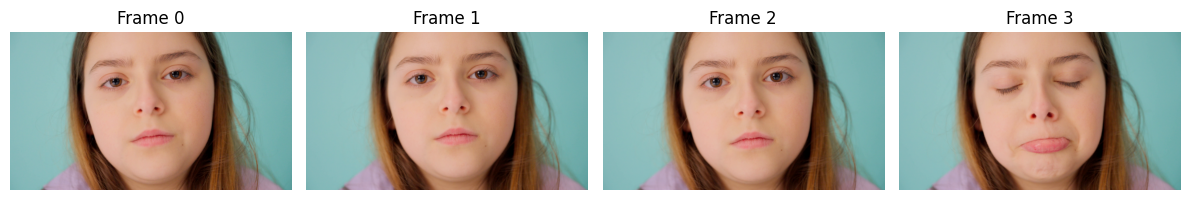

In [ ]:
# Step 5: Display a few sampled frames to verify frame extraction.

plt.figure(figsize=(12, 6))

num_to_show = min(4, len(frames))

for i in range(num_to_show):
    plt.subplot(1, num_to_show, i + 1)
    plt.imshow(frames[i])
    plt.axis("off")
    plt.title(f"Frame {i}")

plt.tight_layout()
plt.show()

## Step 6: Detect and Extract the Face Region

Before applying emotion classification, the system isolates the facial region from each sampled frame.

This helps the model focus on the subject's face rather than the full scene, improving consistency and reducing irrelevant background information.

In [ ]:
# Step 6: Load a Haar Cascade face detector.
# This classical computer vision method is used here as a lightweight
# way to locate the primary face in each sampled frame.

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

def detect_face_with_box(frame):
    """
    Detect the largest face in a frame and return:
    - the cropped face image
    - the bounding box (x, y, w, h)

    If no face is detected, return None values.
    """
    gray = cv2.cvtColor(frame, cv2.COLOR_RGB2GRAY)
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)

    if len(faces) == 0:
        return None, None

    # Choose the largest detected face
    x, y, w, h = max(faces, key=lambda f: f[2] * f[3])
    face_crop = frame[y:y+h, x:x+w]

    return face_crop, (x, y, w, h)

def extract_face(frame):
    """
    Convenience function that returns only the cropped face.
    """
    face_crop, _ = detect_face_with_box(frame)
    return face_crop

##Step 7: Preview Detected Face Crops
The face detector is tested on a few sampled frames.

If detection is successful, the cropped facial region is displayed. This verifies that the next stage, emotion classification, will receive focused facial input.

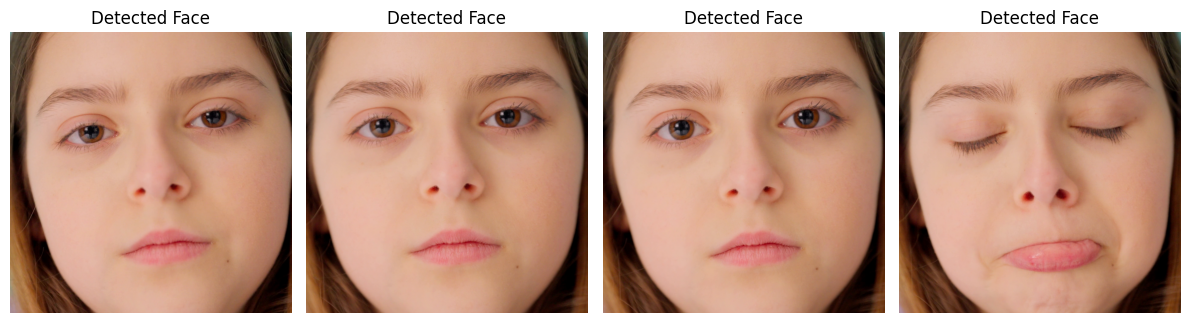

In [ ]:
# Step 7: Display a few extracted face crops.

plt.figure(figsize=(12, 6))

for i in range(min(4, len(frames))):
    face = extract_face(frames[i])

    plt.subplot(1, 4, i + 1)

    if face is not None:
        plt.imshow(face)
        plt.title("Detected Face")
    else:
        plt.imshow(frames[i])
        plt.title("No Face Found")

    plt.axis("off")

plt.tight_layout()
plt.show()

## Step 8: Load the Pretrained Emotion Classifier

The prototype uses the `trpakov/vit-face-expression` model, a Vision Transformer-based facial expression classifier.

Rather than returning only one fixed label, the model produces a ranked list of emotion categories and confidence scores. This is useful because the later generative system can respond to a full emotional distribution rather than a single dominant state.

In [ ]:
# Step 8: Load the pretrained emotion classification pipeline.

emotion_classifier = pipeline(
    "image-classification",
    model="trpakov/vit-face-expression"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/915 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/343M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/228 [00:00<?, ?B/s]

The image processor of type `ViTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


## Step 9: Apply Emotion Classification to the Sampled Frames

Each detected face crop is passed into the pretrained model.

The output for each frame is a ranked list of emotion labels with confidence scores. These scores will later be used as generative control signals.

In [ ]:
# Step 9: Run emotion classification on each sampled frame.
# If no face is found in a frame, store None for that frame.

emotion_outputs = []

for frame in frames:
    face = extract_face(frame)

    if face is None:
        emotion_outputs.append(None)
        continue

    image = Image.fromarray(face)
    result = emotion_classifier(image)
    emotion_outputs.append(result)

print("Processed frames:", len(emotion_outputs))

Processed frames: 11


## Step 10: Convert Emotion Results into a More Usable Dictionary Format

The model returns a ranked list of label-score pairs.

To make these values easier to work with in later stages, each result is converted into a dictionary where emotion labels act as keys and confidence values act as numerical parameters.

In [ ]:
# Step 10: Convert the model output into a dictionary format
# such as {"sad": 0.92, "neutral": 0.04, ...}

def results_to_dict(result):
    return {item["label"]: item["score"] for item in result}

emotion_dicts = []

for result in emotion_outputs:
    if result is None:
        emotion_dicts.append(None)
    else:
        emotion_dicts.append(results_to_dict(result))

print("Emotion dictionaries created:", len(emotion_dicts))

Emotion dictionaries created: 11


## Step 11: Preview Emotion Results

To inspect the classifier output, the top three emotions are printed for a few sample frames.

This helps verify whether the model is responding meaningfully to visible facial changes over time.

In [ ]:
# Step 11: Print the top 3 emotion predictions for the first few frames.

for i, result in enumerate(emotion_outputs[:4]):
    print(f"\nFrame {i}")

    if result is None:
        print("No emotion result")
    else:
        for item in result[:3]:
            print(f"{item['label']}: {item['score']:.2f}")


Frame 0
neutral: 0.95
sad: 0.03
fear: 0.02

Frame 1
neutral: 0.85
sad: 0.12
fear: 0.02

Frame 2
sad: 0.92
neutral: 0.04
fear: 0.03

Frame 3
sad: 0.97
fear: 0.02
neutral: 0.01


## Step 12: Generate a First-Pass Fractal from Emotion Values

The next step is to translate emotion probabilities into generative form.

For this early prototype, the emotion scores are mapped onto parameters of a Julia fractal. This is not yet the final visual system, but it serves as a first proof-of-concept showing how probabilistic emotion can influence computational structure.

In [ ]:
# Step 12: Define a simple function that maps emotion values
# to Julia fractal parameters and returns a fractal image.

def generate_julia_from_emotions(emotions, width=300, height=300):
    """
    Generate a simple Julia fractal based on emotion probabilities.

    Different emotions influence:
    - the real and imaginary parts of the constant c
    - the iteration count
    - the zoom level

    This creates a first-pass visual translation from emotion to form.
    """
    sad = emotions.get("sad", 0)
    fear = emotions.get("fear", 0)
    happy = emotions.get("happy", 0)
    neutral = emotions.get("neutral", 0)
    angry = emotions.get("angry", 0)
    surprise = emotions.get("surprise", 0)

    # Map emotions to Julia parameters
    c_real = -0.8 + fear * 1.2 - sad * 0.3 + happy * 0.2
    c_imag = 0.15 + sad * 0.8 - neutral * 0.3 + surprise * 0.4

    max_iter = int(60 + surprise * 80 + fear * 40)
    zoom = 1.2 + sad * 0.8 + angry * 0.4

    # Create a grid of complex values
    x = np.linspace(-1.5 / zoom, 1.5 / zoom, width)
    y = np.linspace(-1.5 / zoom, 1.5 / zoom, height)
    X, Y = np.meshgrid(x, y)
    Z = X + 1j * Y
    C = complex(c_real, c_imag)

    output = np.zeros(Z.shape, dtype=int)
    mask = np.ones(Z.shape, dtype=bool)

    # Iterate the Julia function
    for i in range(max_iter):
        Z[mask] = Z[mask]**2 + C
        diverged = np.abs(Z) > 2
        newly_diverged = diverged & mask
        output[newly_diverged] = i
        mask[newly_diverged] = False

    output[mask] = max_iter
    return output

## Step 13: Create a Side-by-Side Prototype View

This final prototype view shows three connected stages of the system at once:

1. the detected face  
2. the emotion probabilities  
3. the corresponding generated fractal  

This provides a compact visual summary of the current progress submission.

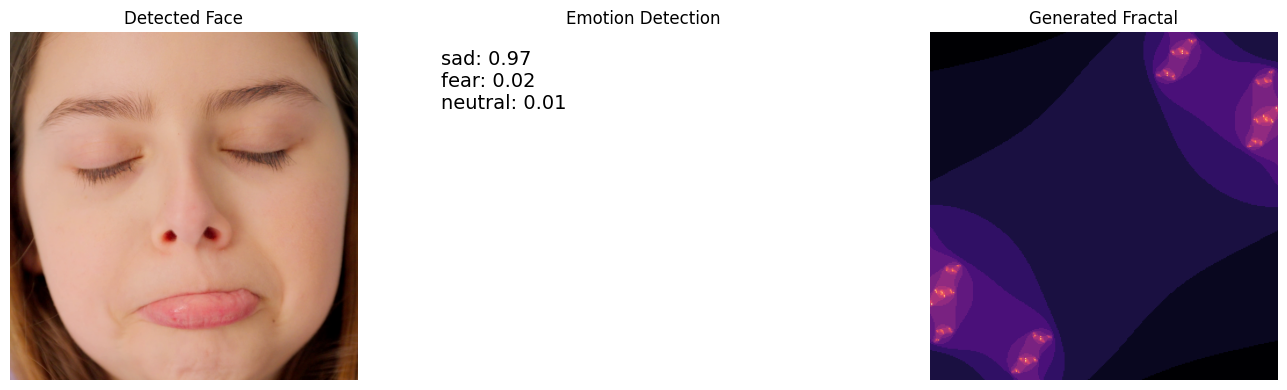

In [ ]:
# Step 13: Display a side-by-side prototype for one selected frame.

frame_index = 3  # Change this value to test different sampled frames

frame = frames[frame_index]
face = extract_face(frame)
result = emotion_outputs[frame_index]

# Handle the case where no emotion result exists
if result is not None:
    emotions = results_to_dict(result)
    fractal = generate_julia_from_emotions(emotions)
    top3 = result[:3]
    emotion_text = "\n".join([f"{r['label']}: {r['score']:.2f}" for r in top3])
else:
    emotions = None
    fractal = np.zeros((300, 300))
    emotion_text = "No emotion result"

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Column 1: detected face
axes[0].imshow(face if face is not None else frame)
axes[0].set_title("Detected Face")
axes[0].axis("off")

# Column 2: emotion text
axes[1].axis("off")
axes[1].text(0.05, 0.95, emotion_text, va="top", fontsize=14)
axes[1].set_title("Emotion Detection")

# Column 3: generated fractal
axes[2].imshow(fractal, cmap="magma")
axes[2].set_title("Generated Fractal")
axes[2].axis("off")

plt.tight_layout()
plt.show()

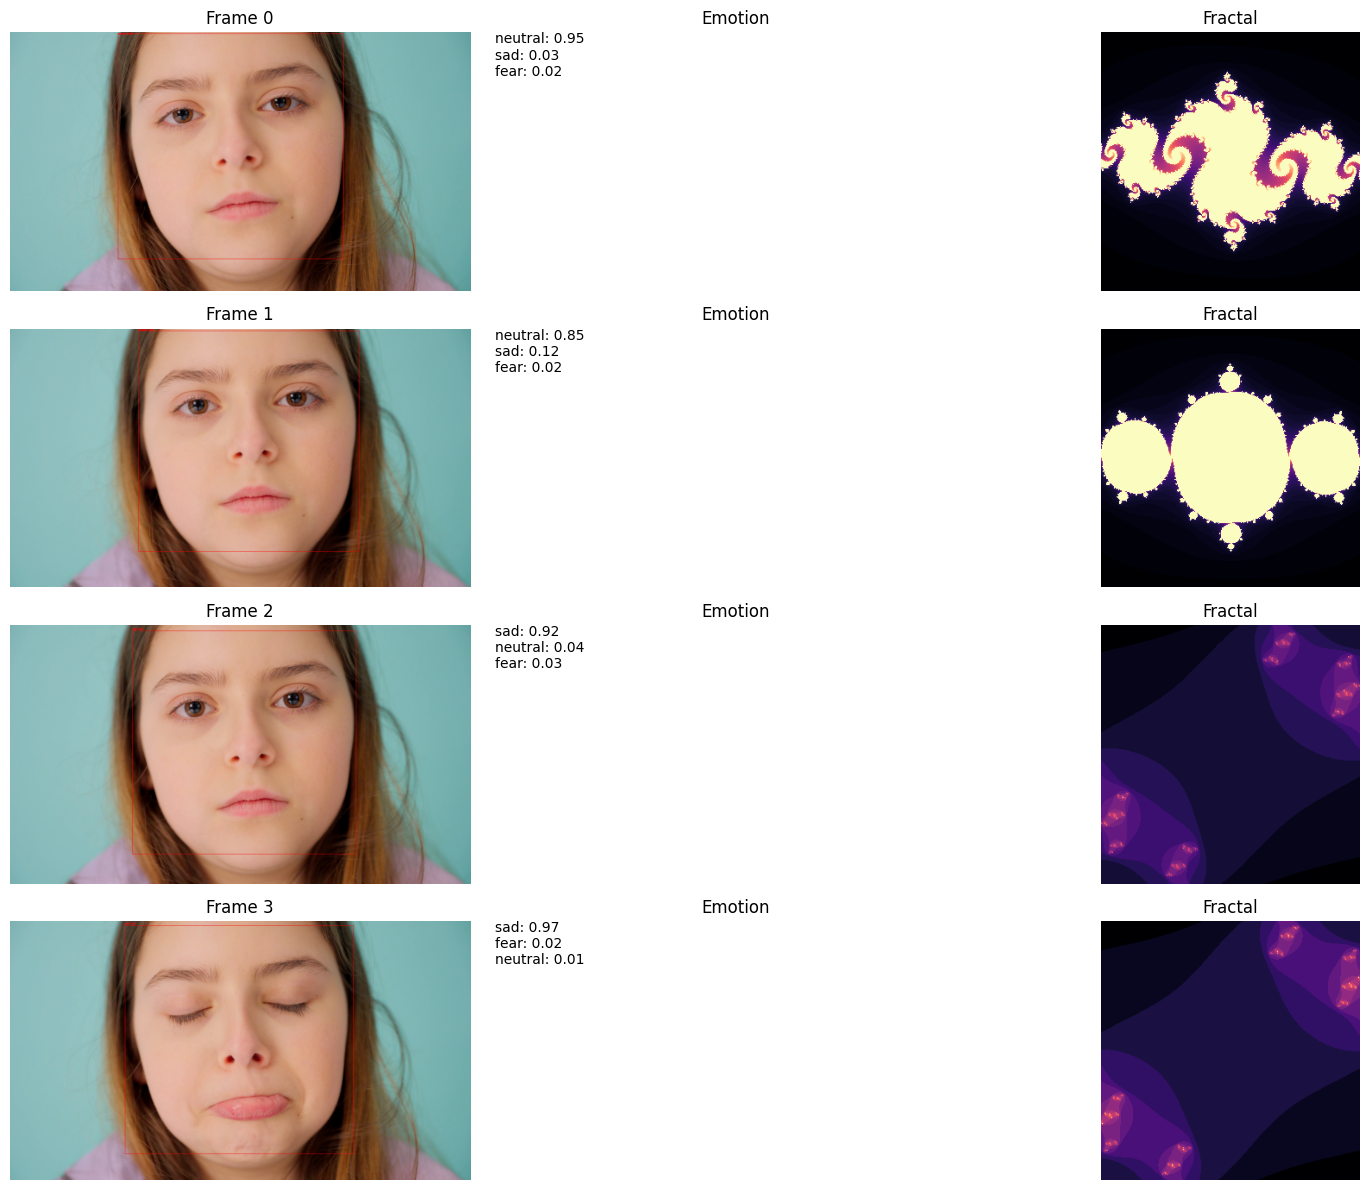

In [ ]:
num_frames = 4

plt.figure(figsize=(15, num_frames * 3))

for i, frame in enumerate(frames[:num_frames]):
    display_frame = frame.copy()
    face, box = detect_face_with_box(frame)

    result_text = "No face detected"
    fractal = np.zeros((300, 300))  # fallback

    if face is not None and box is not None:
        x, y, w, h = box

        # Run emotion model
        image = Image.fromarray(face)
        result = emotion_classifier(image)

        # Format emotion text
        result_text = "\n".join(
            [f"{r['label']}: {r['score']:.2f}" for r in result[:3]]
        )

        # Draw bounding box + label
        top_emotion = result[0]["label"]
        top_score = result[0]["score"]

        cv2.rectangle(display_frame, (x, y), (x + w, y + h), (255, 0, 0), 2)
        cv2.putText(
            display_frame,
            f"{top_emotion}: {top_score:.2f}",
            (x, max(20, y - 10)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (255, 0, 0),
            2,
            cv2.LINE_AA
        )

        # Convert result → dictionary
        emotions = {r["label"]: r["score"] for r in result}

        # Generate fractal
        fractal = generate_julia_from_emotions(emotions)

    # --- COLUMN 1: IMAGE ---
    plt.subplot(num_frames, 3, i * 3 + 1)
    plt.imshow(display_frame)
    plt.axis("off")
    plt.title(f"Frame {i}")

    # --- COLUMN 2: TEXT ---
    plt.subplot(num_frames, 3, i * 3 + 2)
    plt.axis("off")
    plt.text(0, 1, result_text, fontsize=10, va="top")
    plt.title("Emotion")

    # --- COLUMN 3: FRACTAL ---
    plt.subplot(num_frames, 3, i * 3 + 3)
    plt.imshow(fractal, cmap="magma")
    plt.axis("off")
    plt.title("Fractal")

plt.tight_layout()
plt.show()

## Current Result

This prototype establishes a full early-stage pipeline from facial input to generative output:

- a video is processed into sampled frames  
- the face region is detected and extracted  
- a pretrained model predicts emotion probabilities  
- those probabilities are translated into fractal parameters  
- a corresponding fractal image is generated  

Although the current mapping is still experimental, the core project idea is now functioning: emotion probabilities are being used as control signals for computational visual form.

## Next Steps

The next phase of development will focus on refining the system into a more dynamic side-by-side experience.

Planned next steps include:

- applying temporal smoothing across consecutive frames  
- refining emotion-to-visual mappings, especially color palettes tied to specific emotions  
- replacing the current static prototype with an evolving live or video-based side-by-side visualization  
- exploring whether the input should remain a video clip or be extended into real-time webcam input